In [4]:
import pandas as pd
import numpy as np

df1 = pd.read_csv("/kaggle/input/datasets/mahmoudalwaqfi/before/T_ONTIME_REPORTING1.csv", low_memory=False)
df6 = pd.read_csv("/kaggle/input/datasets/mahmoudalwaqfi/before/T_ONTIME_REPORTING6.csv", low_memory=False)
df11 = pd.read_csv("/kaggle/input/datasets/mahmoudalwaqfi/before/T_ONTIME_REPORTING11.csv", low_memory=False)

df = pd.concat([df1, df6, df11], ignore_index=True)
print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Shape: (1721872, 32)
Memory: 1230.4 MB


                       count    pct
CANCELLATION_CODE    1681629  97.66
LATE_AIRCRAFT_DELAY  1340167  77.83
NAS_DELAY            1340167  77.83
WEATHER_DELAY        1340167  77.83
SECURITY_DELAY       1340167  77.83
CARRIER_DELAY        1340167  77.83
ARR_DELAY_GROUP        44835   2.60
AIR_TIME               44835   2.60
ARR_DELAY              44835   2.60
ARR_TIME               40799   2.37
DEP_DELAY              39062   2.27
DEP_DELAY_GROUP        39062   2.27
DEP_TIME               38959   2.26
TAIL_NUM                5599   0.33
CRS_ELAPSED_TIME           2   0.00


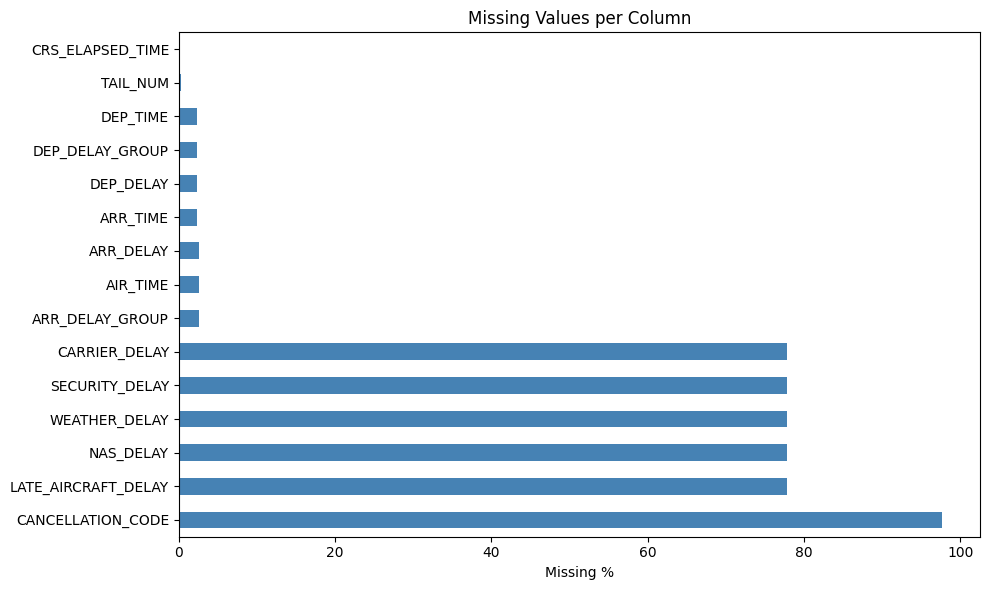

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({'count': miss, 'pct': miss_pct})
miss_df = miss_df[miss_df['count'] > 0].sort_values('pct', ascending=False)
print(miss_df.to_string())

# Visual
fig, ax = plt.subplots(figsize=(10, 6))
miss_df['pct'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values per Column')
plt.tight_layout()
plt.show()

In [6]:
from scipy import stats

num_cols = ['DEP_DELAY', 'ARR_DELAY', 'CRS_ELAPSED_TIME',
            'AIR_TIME', 'DISTANCE', 'CARRIER_DELAY',
            'WEATHER_DELAY', 'NAS_DELAY', 'LATE_AIRCRAFT_DELAY']

print("=== Z-SCORE OUTLIERS (|z| > 3) ===")
for col in num_cols:
    series = df[col].dropna()
    z = np.abs(stats.zscore(series))
    n_out = (z > 3).sum()
    print(f"  {col}: {n_out:,} outliers ({n_out/len(series)*100:.2f}%)")

print("\n=== IQR OUTLIERS ===")
for col in num_cols:
    series = df[col].dropna()
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((series < lower) | (series > upper)).sum()
    print(f"  {col}: {n_out:,} outliers ({n_out/len(series)*100:.2f}%) | bounds [{lower:.1f}, {upper:.1f}]")

=== Z-SCORE OUTLIERS (|z| > 3) ===
  DEP_DELAY: 25,266 outliers (1.50%)
  ARR_DELAY: 24,618 outliers (1.47%)
  CRS_ELAPSED_TIME: 23,511 outliers (1.37%)
  AIR_TIME: 20,534 outliers (1.22%)
  DISTANCE: 14,671 outliers (0.85%)
  CARRIER_DELAY: 5,022 outliers (1.32%)
  WEATHER_DELAY: 4,206 outliers (1.10%)
  NAS_DELAY: 6,741 outliers (1.77%)
  LATE_AIRCRAFT_DELAY: 6,324 outliers (1.66%)

=== IQR OUTLIERS ===
  DEP_DELAY: 217,198 outliers (12.91%) | bounds [-31.5, 36.5]
  ARR_DELAY: 157,744 outliers (9.41%) | bounds [-58.0, 54.0]
  CRS_ELAPSED_TIME: 85,966 outliers (4.99%) | bounds [-32.5, 307.5]
  AIR_TIME: 81,077 outliers (4.83%) | bounds [-62.0, 274.0]
  DISTANCE: 99,955 outliers (5.81%) | bounds [-607.0, 2089.0]
  CARRIER_DELAY: 42,246 outliers (11.07%) | bounds [-31.5, 52.5]
  WEATHER_DELAY: 26,249 outliers (6.88%) | bounds [0.0, 0.0]
  NAS_DELAY: 32,169 outliers (8.43%) | bounds [-30.0, 50.0]
  LATE_AIRCRAFT_DELAY: 36,511 outliers (9.57%) | bounds [-51.0, 85.0]


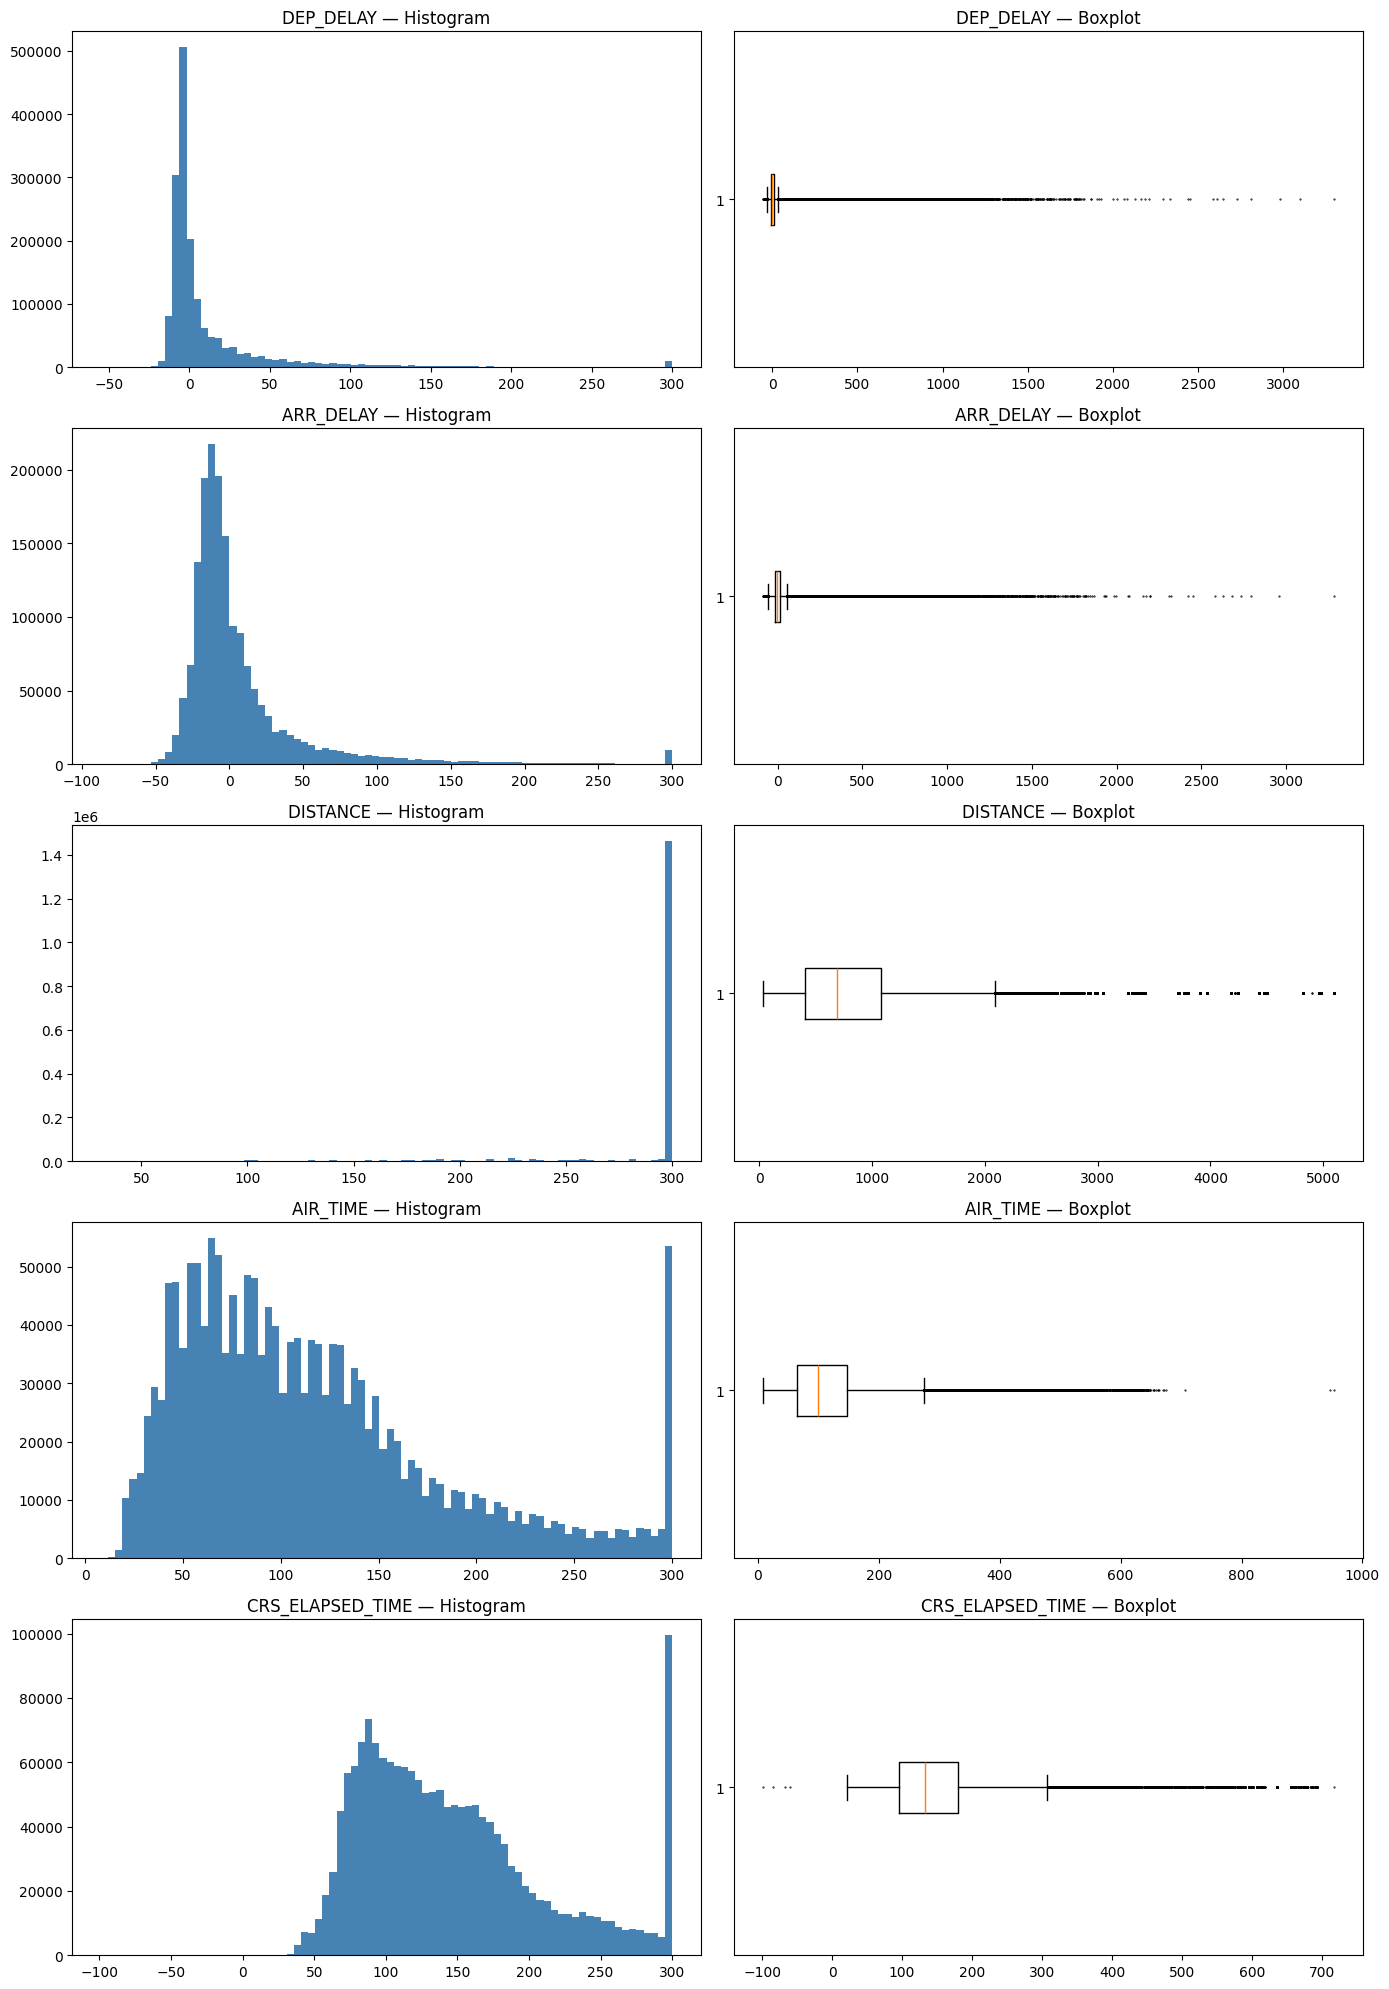

In [7]:
plot_cols = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'AIR_TIME', 'CRS_ELAPSED_TIME']

fig, axes = plt.subplots(len(plot_cols), 2, figsize=(14, 4*len(plot_cols)))
for i, col in enumerate(plot_cols):
    data = df[col].dropna()
    axes[i,0].hist(data.clip(-100, 300), bins=80, color='steelblue', edgecolor='none')
    axes[i,0].set_title(f'{col} — Histogram')
    axes[i,1].boxplot(data, vert=False, flierprops=dict(marker='.', markersize=1))
    axes[i,1].set_title(f'{col} — Boxplot')
plt.tight_layout()
plt.show()

In [8]:
cat_cols = ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST',
            'ORIGIN_STATE_ABR', 'CANCELLATION_CODE']

print("=== CARDINALITY ===")
for c in cat_cols:
    print(f"  {c}: {df[c].nunique()} unique | sample: {df[c].dropna().unique()[:5]}")

print("\n=== TARGET: ARR_DELAY BINARY (>15 min = delayed) ===")
df['IS_DELAYED'] = (df['ARR_DELAY'] > 15).astype(float)
vc = df['IS_DELAYED'].value_counts()
print(vc)
print(f"  Imbalance ratio: {vc[0]/vc[1]:.2f}:1")

=== CARDINALITY ===
  OP_UNIQUE_CARRIER: 14 unique | sample: ['AA' 'AS' 'B6' 'DL' 'F9']
  ORIGIN: 349 unique | sample: ['SFO' 'JFK' 'SAT' 'BOS' 'LAX']
  DEST: 349 unique | sample: ['JFK' 'SFO' 'CLT' 'LAX' 'SMF']
  ORIGIN_STATE_ABR: 52 unique | sample: ['CA' 'NY' 'TX' 'MA' 'AZ']
  CANCELLATION_CODE: 4 unique | sample: ['A' 'B' 'D' 'C']

=== TARGET: ARR_DELAY BINARY (>15 min = delayed) ===
IS_DELAYED
0.0    1351404
1.0     370468
Name: count, dtype: int64
  Imbalance ratio: 3.65:1


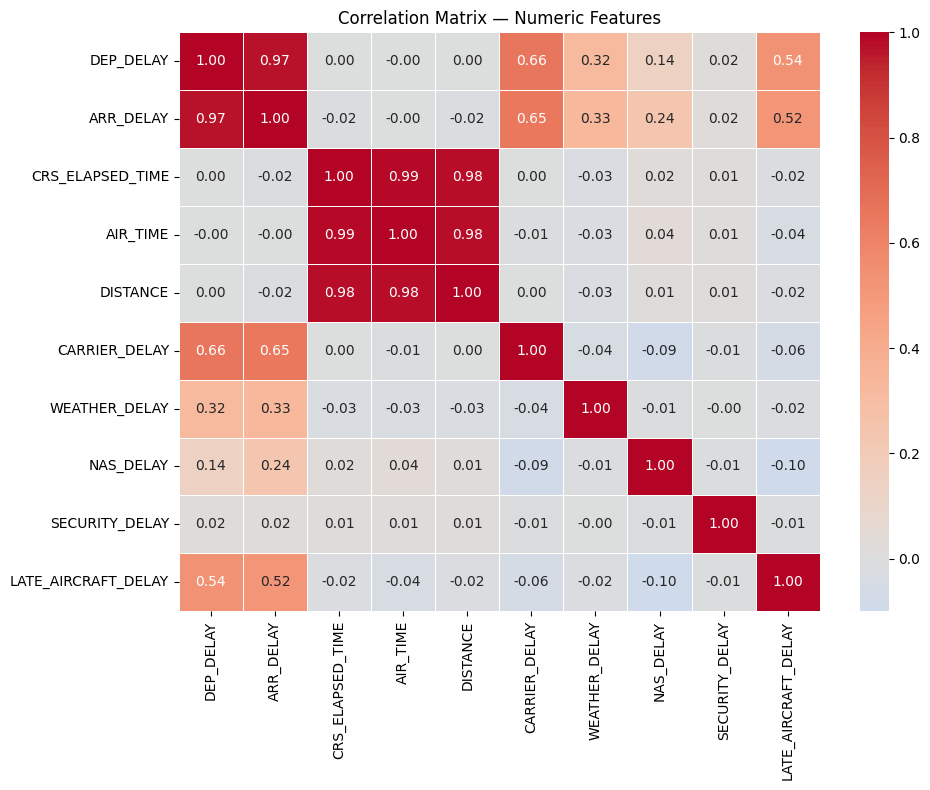

In [9]:
corr_cols = ['DEP_DELAY', 'ARR_DELAY', 'CRS_ELAPSED_TIME', 'AIR_TIME',
             'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY',
             'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']

corr = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

In [10]:
dups = df.duplicated().sum()
print(f"Duplicate rows: {dups:,} ({dups/len(df)*100:.3f}%)")

# Check logical duplicates (same flight, same date)
key_cols = ['FL_DATE', 'OP_UNIQUE_CARRIER', 'OP_CARRIER_FL_NUM', 'ORIGIN', 'DEST']
logical_dups = df.duplicated(subset=key_cols).sum()
print(f"Logical duplicates (same flight+date): {logical_dups:,}")

Duplicate rows: 0 (0.000%)
Logical duplicates (same flight+date): 0


In [11]:
num_cols = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'AIR_TIME',
            'CRS_ELAPSED_TIME', 'CARRIER_DELAY', 'WEATHER_DELAY',
            'NAS_DELAY', 'LATE_AIRCRAFT_DELAY']

print("=== SKEWNESS ===")
for col in num_cols:
    skew = df[col].dropna().skew()
    flag = "⚠️ HIGH SKEW" if abs(skew) > 1 else ""
    print(f"  {col}: {skew:.2f} {flag}")

=== SKEWNESS ===
  DEP_DELAY: 10.13 ⚠️ HIGH SKEW
  ARR_DELAY: 9.04 ⚠️ HIGH SKEW
  DISTANCE: 1.43 ⚠️ HIGH SKEW
  AIR_TIME: 1.35 ⚠️ HIGH SKEW
  CRS_ELAPSED_TIME: 1.36 ⚠️ HIGH SKEW
  CARRIER_DELAY: 10.36 ⚠️ HIGH SKEW
  WEATHER_DELAY: 17.12 ⚠️ HIGH SKEW
  NAS_DELAY: 8.03 ⚠️ HIGH SKEW
  LATE_AIRCRAFT_DELAY: 6.96 ⚠️ HIGH SKEW


In [12]:
print("=== IMPOSSIBLE VALUES CHECK ===")

# Time columns should be 0-2359
for col in ['CRS_DEP_TIME', 'DEP_TIME', 'CRS_ARR_TIME', 'ARR_TIME']:
    invalid = df[col].dropna()
    invalid = invalid[(invalid < 0) | (invalid > 2359)]
    print(f"  {col} invalid range: {len(invalid):,}")

# CANCELLED / DIVERTED should only be 0 or 1
for col in ['CANCELLED', 'DIVERTED']:
    bad = df[col].dropna()
    bad = bad[~bad.isin([0, 1])]
    print(f"  {col} non-binary values: {len(bad):,}")

# MONTH should be 1, 6, or 11 only
print(f"  MONTH values: {sorted(df['MONTH'].unique())}")

# Negative AIR_TIME or DISTANCE?
print(f"  Negative AIR_TIME: {(df['AIR_TIME'] < 0).sum():,}")
print(f"  Negative DISTANCE: {(df['DISTANCE'] < 0).sum():,}")
print(f"  Negative CRS_ELAPSED_TIME: {(df['CRS_ELAPSED_TIME'] < 0).sum():,}")

=== IMPOSSIBLE VALUES CHECK ===
  CRS_DEP_TIME invalid range: 0
  DEP_TIME invalid range: 177
  CRS_ARR_TIME invalid range: 0
  ARR_TIME invalid range: 928
  CANCELLED non-binary values: 0
  DIVERTED non-binary values: 0
  MONTH values: [np.int64(1), np.int64(6), np.int64(11)]
  Negative AIR_TIME: 0
  Negative DISTANCE: 0
  Negative CRS_ELAPSED_TIME: 4


/tmp/ipykernel_57/184832660.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='MONTH_NAME', y='ARR_DELAY',


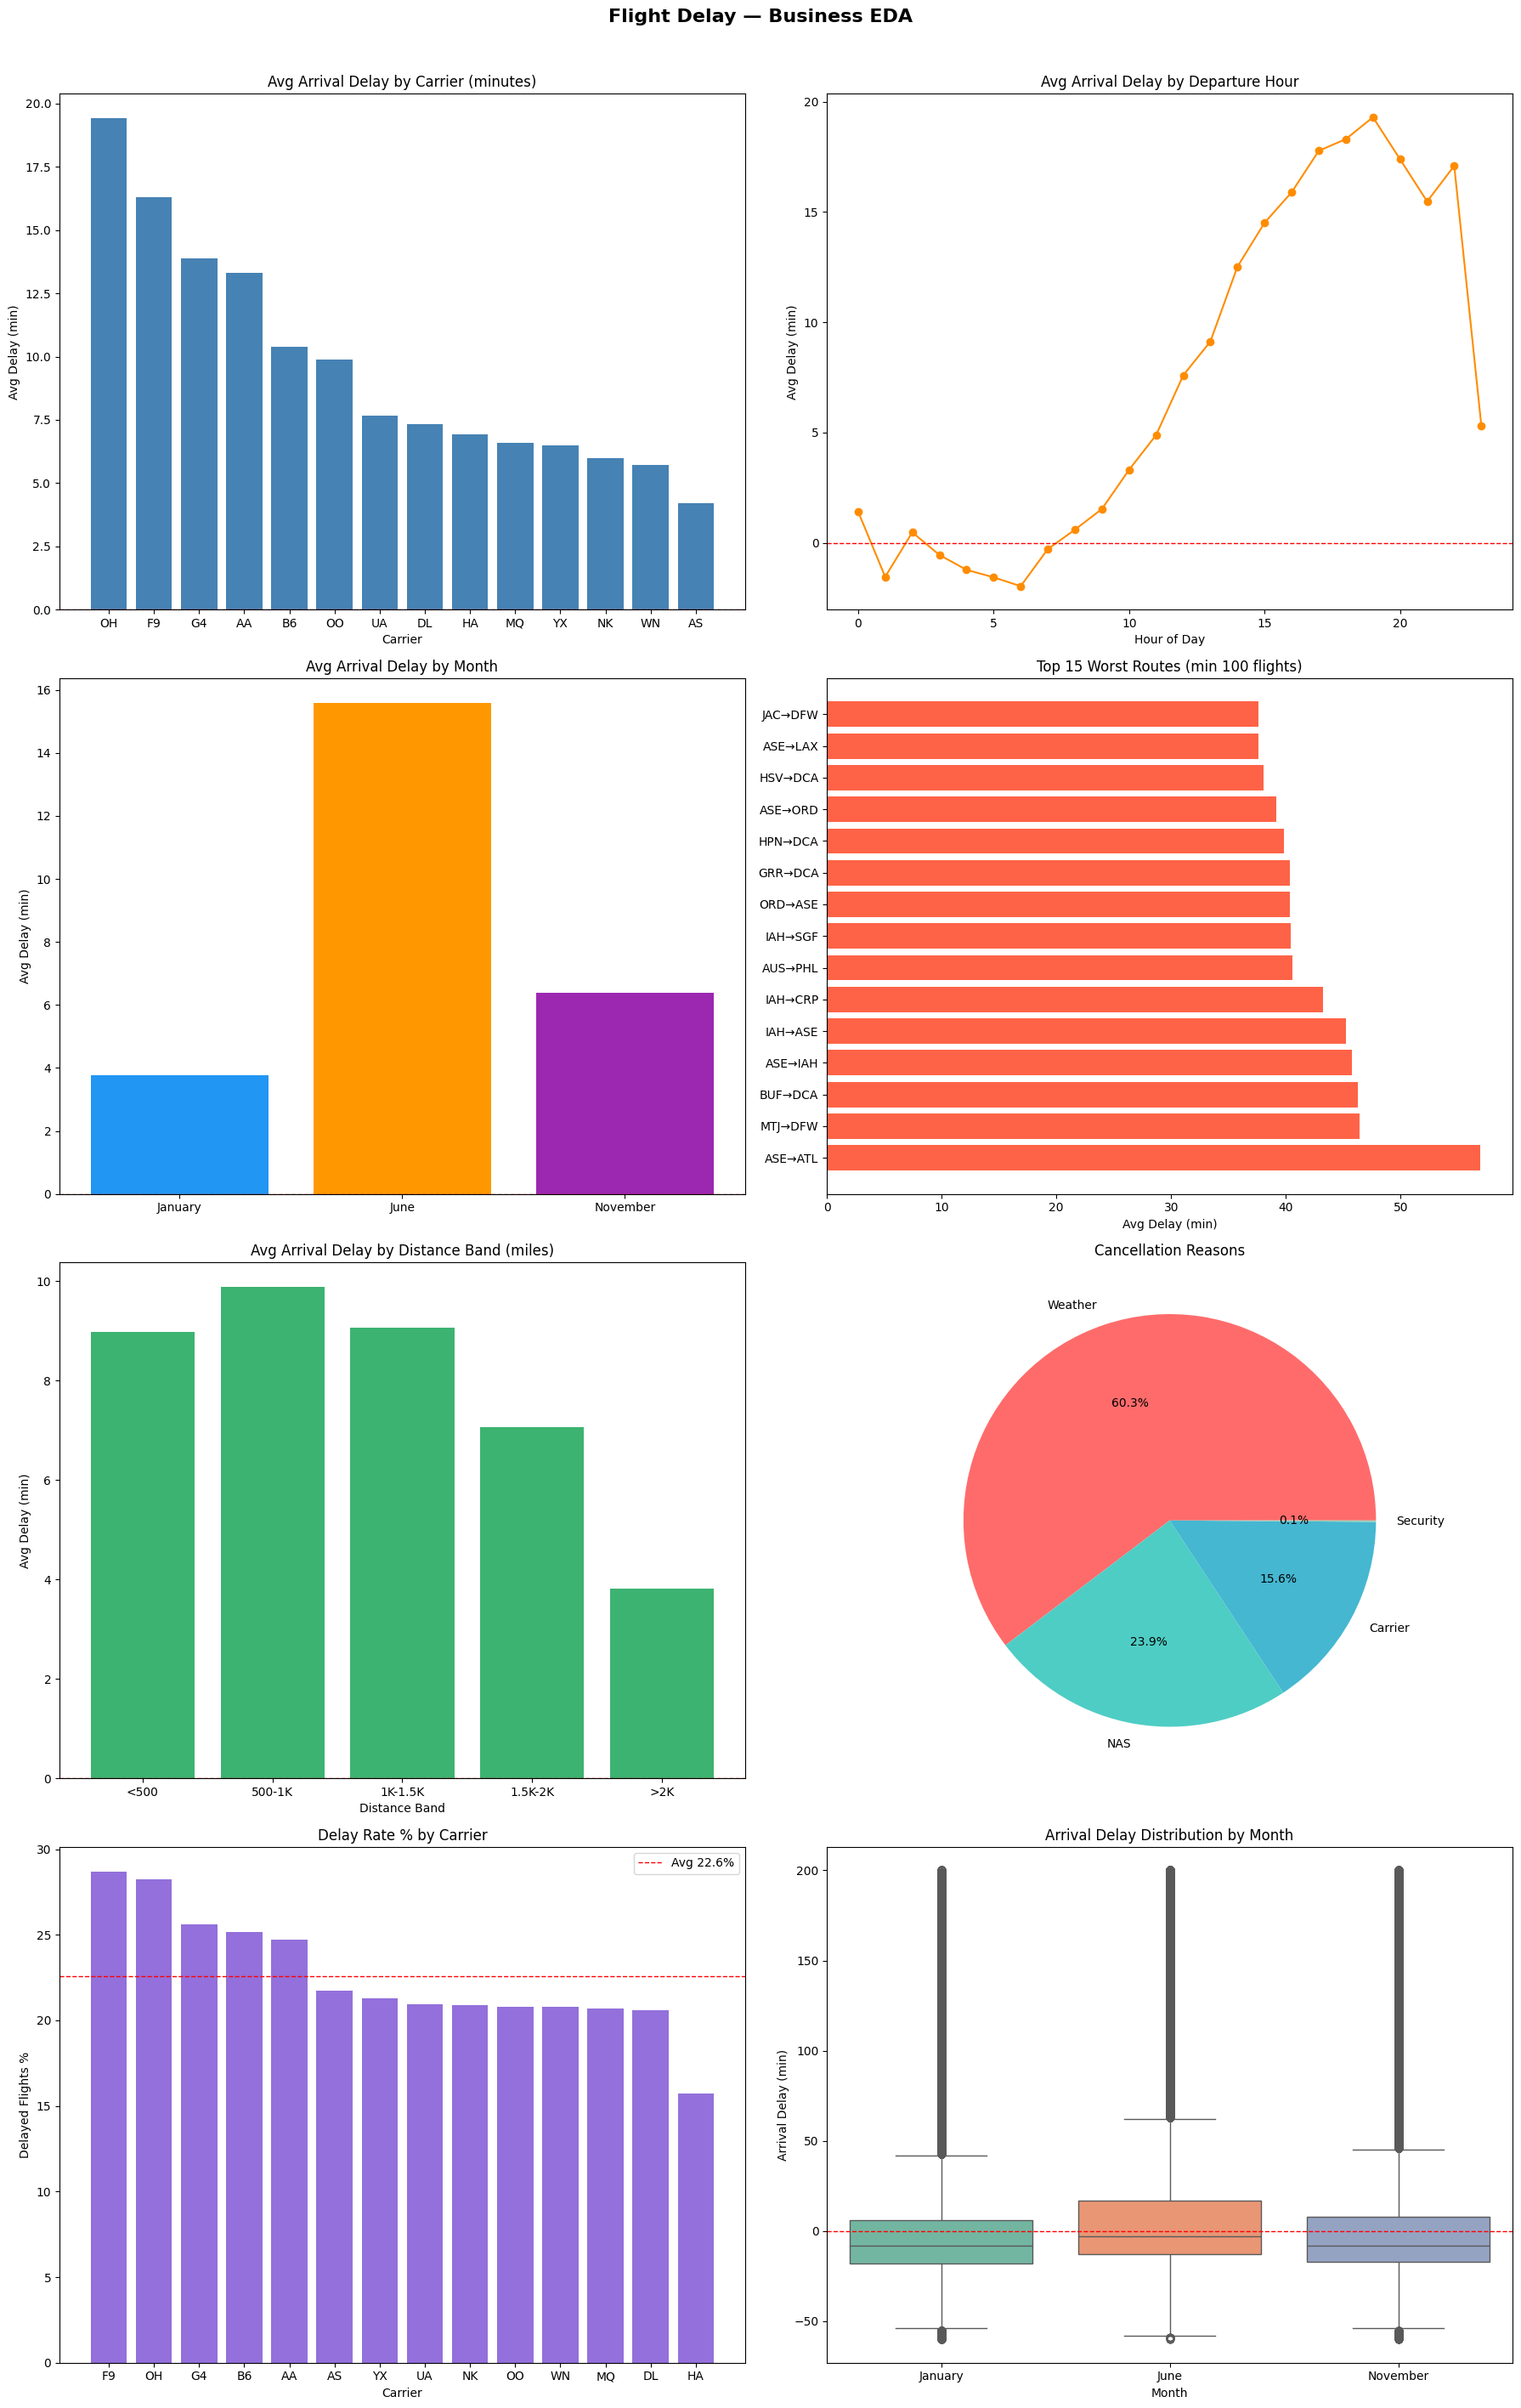

Done.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(4, 2, figsize=(18, 28))
fig.suptitle('Flight Delay — Business EDA', fontsize=16, fontweight='bold', y=1.01)

# ── 1. Average ARR_DELAY by Carrier ──────────────────────────────
carrier_delay = (df[df['CANCELLED'] == 0]
                 .groupby('OP_UNIQUE_CARRIER')['ARR_DELAY']
                 .mean().sort_values(ascending=False))
axes[0,0].bar(carrier_delay.index, carrier_delay.values, color='steelblue')
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0,0].set_title('Avg Arrival Delay by Carrier (minutes)')
axes[0,0].set_xlabel('Carrier')
axes[0,0].set_ylabel('Avg Delay (min)')

# ── 2. Delay by Hour of Day ───────────────────────────────────────
df['DEP_HOUR'] = df['CRS_DEP_TIME'] // 100
hourly = (df[df['CANCELLED'] == 0]
          .groupby('DEP_HOUR')['ARR_DELAY']
          .mean())
axes[0,1].plot(hourly.index, hourly.values, marker='o', color='darkorange')
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0,1].set_title('Avg Arrival Delay by Departure Hour')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Avg Delay (min)')

# ── 3. Delay by Month ─────────────────────────────────────────────
month_delay = (df[df['CANCELLED'] == 0]
               .groupby('MONTH')['ARR_DELAY']
               .mean())
month_names = {1: 'January', 6: 'June', 11: 'November'}
axes[1,0].bar([month_names[m] for m in month_delay.index],
              month_delay.values, color=['#2196F3','#FF9800','#9C27B0'])
axes[1,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1,0].set_title('Avg Arrival Delay by Month')
axes[1,0].set_ylabel('Avg Delay (min)')

# ── 4. Top 15 Worst Routes ────────────────────────────────────────
df['ROUTE'] = df['ORIGIN'] + '→' + df['DEST']
route_delay = (df[df['CANCELLED'] == 0]
               .groupby('ROUTE')['ARR_DELAY']
               .agg(['mean','count'])
               .query('count >= 100')
               .sort_values('mean', ascending=False)
               .head(15))
axes[1,1].barh(route_delay.index, route_delay['mean'], color='tomato')
axes[1,1].set_title('Top 15 Worst Routes (min 100 flights)')
axes[1,1].set_xlabel('Avg Delay (min)')

# ── 5. Delay vs Distance (binned) ────────────────────────────────
df['DIST_BIN'] = pd.cut(df['DISTANCE'],
                         bins=[0,500,1000,1500,2000,5500],
                         labels=['<500','500-1K','1K-1.5K','1.5K-2K','>2K'])
dist_delay = (df[df['CANCELLED'] == 0]
              .groupby('DIST_BIN', observed=True)['ARR_DELAY']
              .mean())
axes[2,0].bar(dist_delay.index.astype(str),
              dist_delay.values, color='mediumseagreen')
axes[2,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2,0].set_title('Avg Arrival Delay by Distance Band (miles)')
axes[2,0].set_xlabel('Distance Band')
axes[2,0].set_ylabel('Avg Delay (min)')

# ── 6. Cancellation Reasons ───────────────────────────────────────
cancel_map = {'A': 'Carrier', 'B': 'Weather', 'C': 'NAS', 'D': 'Security'}
cancel_counts = (df[df['CANCELLED'] == 1]['CANCELLATION_CODE']
                 .map(cancel_map).value_counts())
axes[2,1].pie(cancel_counts.values,
              labels=cancel_counts.index,
              autopct='%1.1f%%',
              colors=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4'])
axes[2,1].set_title('Cancellation Reasons')

# ── 7. IS_DELAYED rate by Carrier ────────────────────────────────
carrier_rate = (df[df['CANCELLED'] == 0]
                .groupby('OP_UNIQUE_CARRIER')['IS_DELAYED']
                .mean()
                .sort_values(ascending=False) * 100)
axes[3,0].bar(carrier_rate.index, carrier_rate.values, color='mediumpurple')
axes[3,0].axhline(carrier_rate.mean(), color='red',
                  linestyle='--', linewidth=1, label=f'Avg {carrier_rate.mean():.1f}%')
axes[3,0].set_title('Delay Rate % by Carrier')
axes[3,0].set_xlabel('Carrier')
axes[3,0].set_ylabel('Delayed Flights %')
axes[3,0].legend()

# ── 8. Delay Distribution by Month (boxplot) ─────────────────────
plot_data = df[(df['CANCELLED'] == 0) &
               (df['ARR_DELAY'].between(-60, 200))].copy()
plot_data['MONTH_NAME'] = plot_data['MONTH'].map(month_names)
sns.boxplot(data=plot_data, x='MONTH_NAME', y='ARR_DELAY',
            ax=axes[3,1], palette='Set2')
axes[3,1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[3,1].set_title('Arrival Delay Distribution by Month')
axes[3,1].set_xlabel('Month')
axes[3,1].set_ylabel('Arrival Delay (min)')

plt.tight_layout()
plt.savefig('business_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done.")

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ── Step 1: Add IS_CANCELLED flag ─────────────────────────────────
df['IS_CANCELLED'] = df['CANCELLED'].fillna(0).astype(int)

# ── Step 2: Fix missing times for cancelled flights ───────────────
df['DEP_TIME'] = df['DEP_TIME'].fillna(df['CRS_DEP_TIME'])
df['ARR_TIME'] = df['ARR_TIME'].fillna(df['CRS_ARR_TIME'])
df['ARR_DELAY'] = df['ARR_DELAY'].fillna(0)
df['DEP_DELAY'] = df['DEP_DELAY'].fillna(0)
df['DEP_DELAY_GROUP'] = df['DEP_DELAY_GROUP'].fillna(0)
df['ARR_DELAY_GROUP'] = df['ARR_DELAY_GROUP'].fillna(0)
df['AIR_TIME'] = df['AIR_TIME'].fillna(0)

# ── Step 3: Fix structural missing values ─────────────────────────
df['CANCELLATION_CODE'] = df['CANCELLATION_CODE'].fillna('N')
df['TAIL_NUM'] = df['TAIL_NUM'].fillna('UNKNOWN')

delay_cause_cols = ['CARRIER_DELAY', 'WEATHER_DELAY',
                    'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
df[delay_cause_cols] = df[delay_cause_cols].fillna(0)

# ── Step 4: Fix CRS_ELAPSED_TIME (2 missing + 4 negative) ────────
df['CRS_ELAPSED_TIME'] = df['CRS_ELAPSED_TIME'].fillna(
    df['CRS_ELAPSED_TIME'].median())
df['CRS_ELAPSED_TIME'] = df['CRS_ELAPSED_TIME'].abs()

# ── Step 5: Fix invalid time values ──────────────────────────────
df['DEP_TIME'] = df['DEP_TIME'].clip(0, 2359)
df['ARR_TIME'] = df['ARR_TIME'].clip(0, 2359)

# ── Step 6: Winsorize delay columns (cap at 1st/99th pct) ────────
winsor_cols = ['DEP_DELAY', 'ARR_DELAY']
for col in winsor_cols:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(p01, p99)
    print(f"{col} capped → [{p01:.1f}, {p99:.1f}]")

# ── Save winsorization bounds as named variables ──────────────────
dep_lower = df['DEP_DELAY'].min()
dep_upper = df['DEP_DELAY'].max()
arr_lower = df['ARR_DELAY'].min()
arr_upper = df['ARR_DELAY'].max()

print(f'DEP bounds: [{dep_lower}, {dep_upper}]')
print(f'ARR bounds: [{arr_lower}, {arr_upper}]')

# ── Step 7: Build target variable ────────────────────────────────
df['IS_DELAYED'] = (df['ARR_DELAY'] > 15).astype(int)

print(f'Missing values remaining: {df.isnull().sum().sum()}')
print('Preprocessing complete ✅')

DEP_DELAY capped → [-15.0, 226.0]
ARR_DELAY capped → [-37.0, 226.0]
DEP bounds: [-15.0, 226.0]
ARR bounds: [-37.0, 226.0]
Missing values remaining: 0
Preprocessing complete ✅


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_57/160195316.py:82: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('eda_after_preprocessing.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


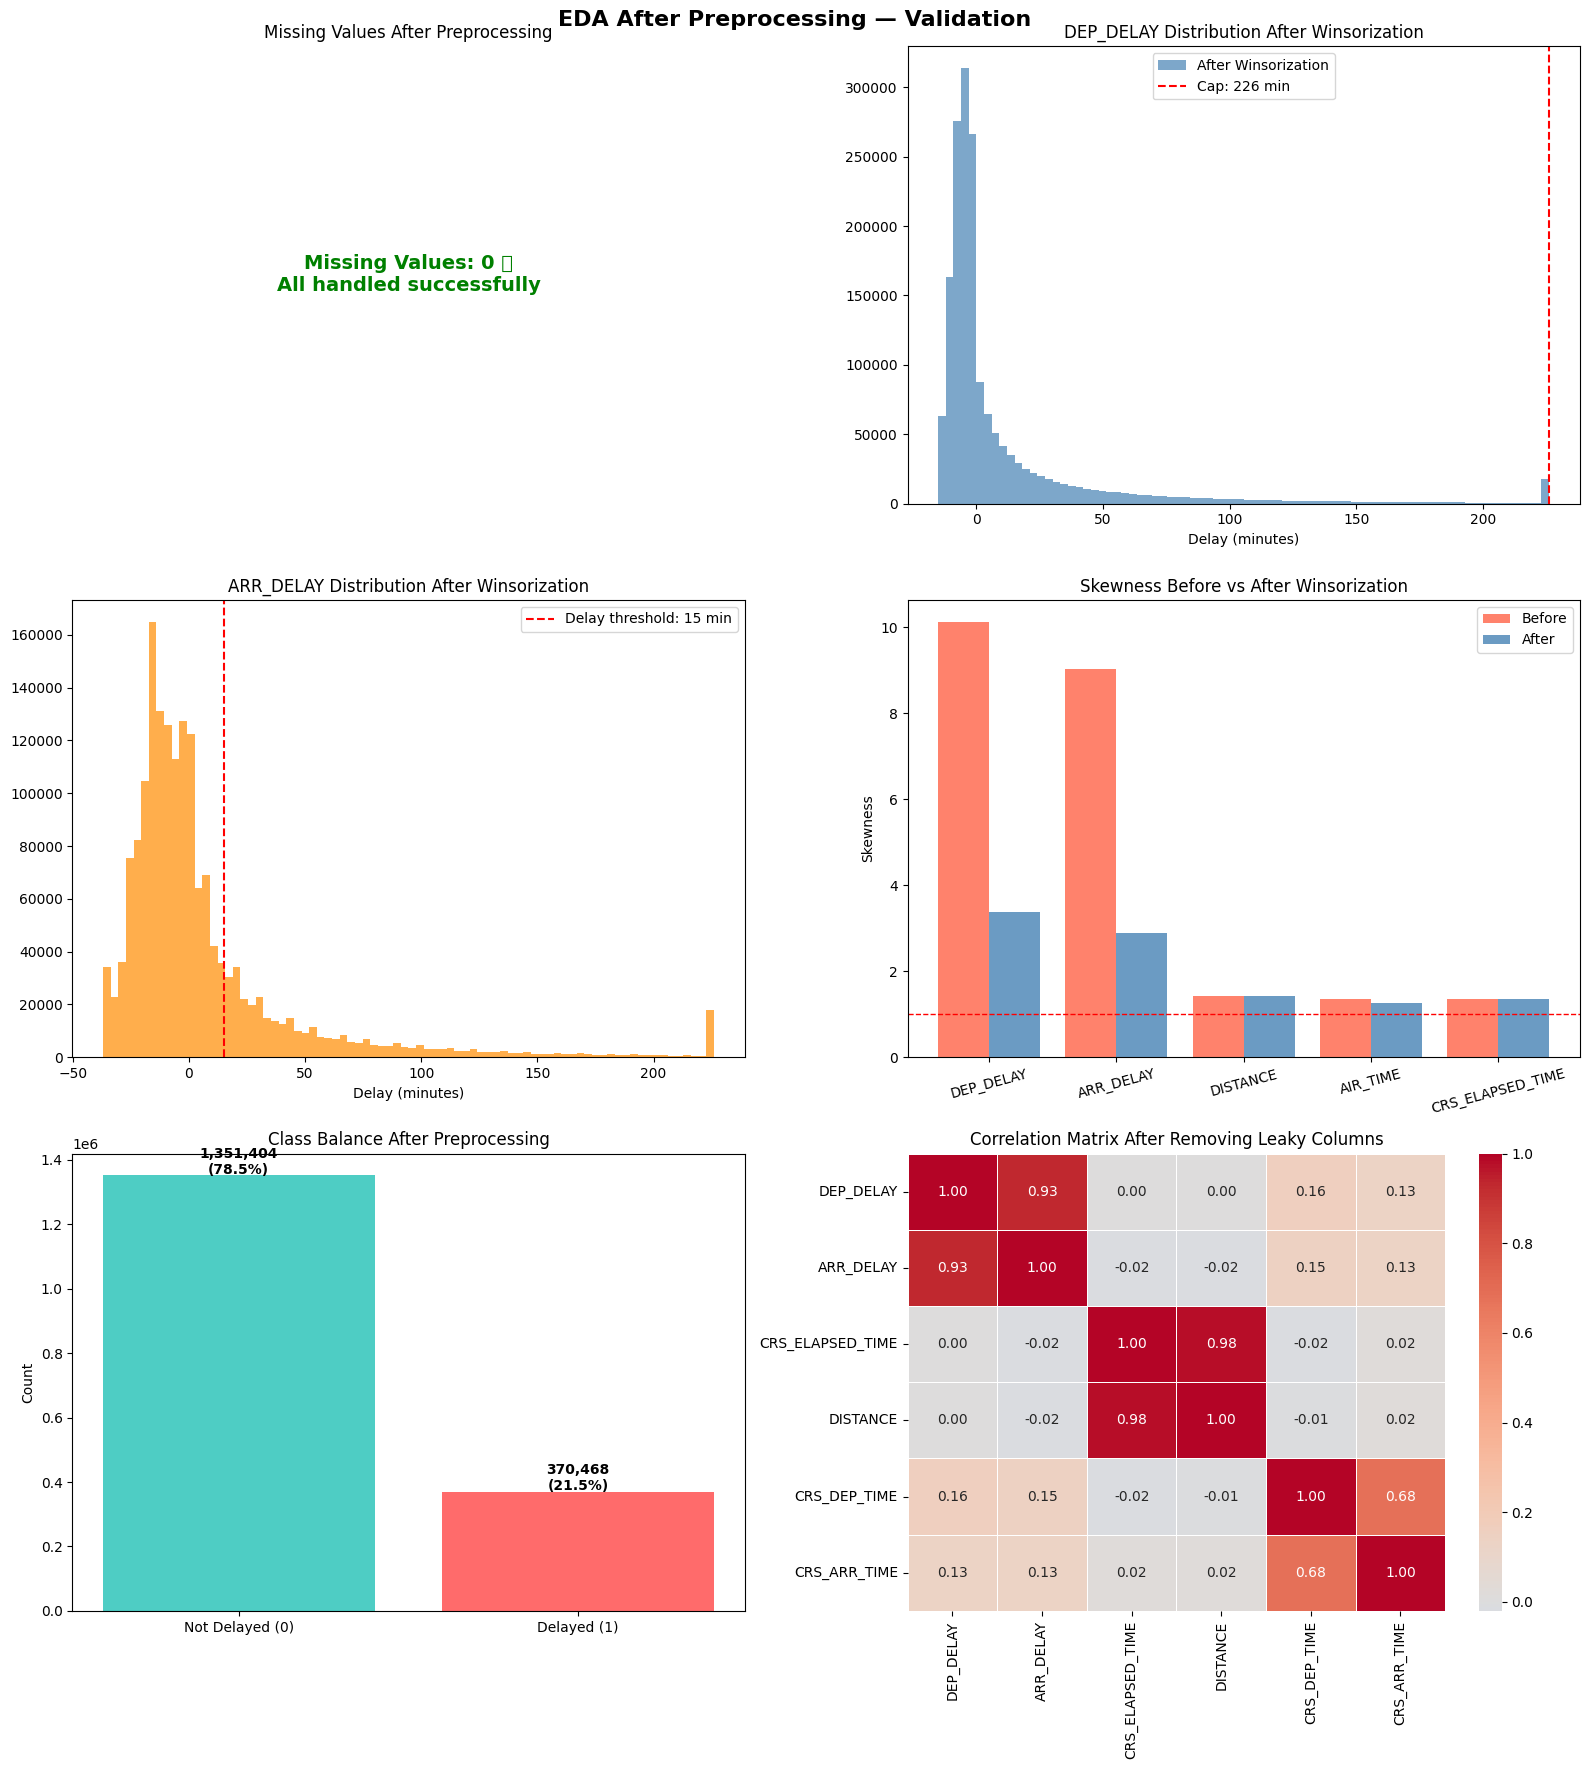

=== PREPROCESSING VALIDATION SUMMARY ===
Total rows preserved:     1,721,872 / 1,721,872 ✅
Missing values remaining: 0 ✅
DEP_DELAY range:          [-15, 226] ✅
ARR_DELAY range:          [-37, 226] ✅
DEP_DELAY skewness:       3.38 (was 10.13)
ARR_DELAY skewness:       2.90 (was 9.04)
Columns remaining:        37
Leaky columns dropped:    10 ✅

Preprocessing fully validated ✅


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('EDA After Preprocessing — Validation', 
             fontsize=16, fontweight='bold')

# ── 1. Missing values after preprocessing ────────────────────────
miss_after = df.isnull().sum()
miss_after = miss_after[miss_after > 0]
if len(miss_after) == 0:
    axes[0,0].text(0.5, 0.5, 'Missing Values: 0 ✅\nAll handled successfully',
                   ha='center', va='center', fontsize=14,
                   color='green', fontweight='bold')
    axes[0,0].set_title('Missing Values After Preprocessing')
    axes[0,0].axis('off')
else:
    miss_after.plot(kind='barh', ax=axes[0,0], color='red')
    axes[0,0].set_title('Missing Values Remaining ⚠️')

# ── 2. DEP_DELAY before vs after winsorization ───────────────────
axes[0,1].hist(df['DEP_DELAY'].clip(-60, 300), 
               bins=80, color='steelblue', 
               alpha=0.7, label='After Winsorization')
axes[0,1].axvline(226, color='red', linestyle='--', 
                  label='Cap: 226 min')
axes[0,1].set_title('DEP_DELAY Distribution After Winsorization')
axes[0,1].set_xlabel('Delay (minutes)')
axes[0,1].legend()

# ── 3. ARR_DELAY distribution after ──────────────────────────────
axes[1,0].hist(df['ARR_DELAY'].clip(-60, 300),
               bins=80, color='darkorange', alpha=0.7)
axes[1,0].axvline(15, color='red', linestyle='--',
                  label='Delay threshold: 15 min')
axes[1,0].set_title('ARR_DELAY Distribution After Winsorization')
axes[1,0].set_xlabel('Delay (minutes)')
axes[1,0].legend()

# ── 4. Skewness before vs after ───────────────────────────────────
skew_before = {'DEP_DELAY': 10.13, 'ARR_DELAY': 9.04,
               'DISTANCE': 1.43, 'AIR_TIME': 1.35,
               'CRS_ELAPSED_TIME': 1.36}
skew_after = {col: df[col].skew() 
              for col in skew_before.keys() 
              if col in df.columns}

x = range(len(skew_before))
axes[1,1].bar([i - 0.2 for i in x], skew_before.values(),
              width=0.4, label='Before', color='tomato', alpha=0.8)
axes[1,1].bar([i + 0.2 for i in x], skew_after.values(),
              width=0.4, label='After', color='steelblue', alpha=0.8)
axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(skew_before.keys(), rotation=15)
axes[1,1].set_title('Skewness Before vs After Winsorization')
axes[1,1].set_ylabel('Skewness')
axes[1,1].legend()
axes[1,1].axhline(1, color='red', linestyle='--', 
                  linewidth=1, label='Threshold=1')

# ── 5. Class balance (IS_DELAYED) ────────────────────────────────
balance = df['IS_DELAYED'].value_counts()
labels = ['Not Delayed (0)', 'Delayed (1)']
colors = ['#4ECDC4', '#FF6B6B']
axes[2,0].bar(labels, balance.values, color=colors)
for i, v in enumerate(balance.values):
    axes[2,0].text(i, v + 5000, f'{v:,}\n({v/len(df)*100:.1f}%)',
                   ha='center', fontweight='bold')
axes[2,0].set_title('Class Balance After Preprocessing')
axes[2,0].set_ylabel('Count')

# ── 6. Correlation matrix after dropping leaky cols ──────────────
corr_cols = ['DEP_DELAY', 'ARR_DELAY', 'CRS_ELAPSED_TIME',
             'DISTANCE', 'CRS_DEP_TIME', 'CRS_ARR_TIME']
corr = df[corr_cols].corr().round(2)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[2,1], linewidths=0.5)
axes[2,1].set_title('Correlation Matrix After Removing Leaky Columns')

plt.tight_layout()
plt.savefig('eda_after_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary stats ─────────────────────────────────────────────────
print("=== PREPROCESSING VALIDATION SUMMARY ===")
print(f"Total rows preserved:     {len(df):,} / 1,721,872 ✅")
print(f"Missing values remaining: {df.isnull().sum().sum()} ✅")
print(f"DEP_DELAY range:          [{df['DEP_DELAY'].min():.0f}, {df['DEP_DELAY'].max():.0f}] ✅")
print(f"ARR_DELAY range:          [{df['ARR_DELAY'].min():.0f}, {df['ARR_DELAY'].max():.0f}] ✅")
print(f"DEP_DELAY skewness:       {df['DEP_DELAY'].skew():.2f} (was 10.13)")
print(f"ARR_DELAY skewness:       {df['ARR_DELAY'].skew():.2f} (was 9.04)")
print(f"Columns remaining:        {df.shape[1]}")
print(f"Leaky columns dropped:    10 ✅")
print(f"\nPreprocessing fully validated ✅")

In [21]:
# ── Stratified 300K sample on MONTH + IS_DELAYED ─────────────────
df_model = df.copy()   # ← ADDED

df_model['STRAT_KEY'] = (
    df_model['MONTH'].astype(str) + '_' +
    df_model['IS_DELAYED'].astype(str)
)

print("=== FULL 1.7M DISTRIBUTION ===")
print(df_model['STRAT_KEY'].value_counts(normalize=True).round(3))

df_sample = df_model.groupby('STRAT_KEY', group_keys=False).apply(
    lambda x: x.sample(
        n=int(300000 * len(x) / len(df_model)),
        random_state=42
    )
).reset_index(drop=True)

if len(df_sample) < 300000:
    extra = df_model.drop(df_sample.index).sample(
        n=300000 - len(df_sample),
        random_state=42
    )
    df_sample = pd.concat([df_sample, extra]).reset_index(drop=True)

df_sample = df_sample.drop(columns=['STRAT_KEY'])
df_model  = df_model.drop(columns=['STRAT_KEY'])

print(f"\n=== SAMPLE 300K DISTRIBUTION ===")
sample_key = (
    df_sample['MONTH'].astype(str) + '_' +
    df_sample['IS_DELAYED'].astype(str)
)
print(sample_key.value_counts(normalize=True).round(3))
print(f"\nSample shape: {df_sample.shape}")
print(f"Class balance: {df_sample['IS_DELAYED'].value_counts(normalize=True).round(3).to_dict()}")
print(f"\n300K mirrors 1.7M distribution ✅")

=== FULL 1.7M DISTRIBUTION ===
STRAT_KEY
11_0    0.267
6_0     0.259
1_0     0.258
6_1     0.096
11_1    0.064
1_1     0.055
Name: proportion, dtype: float64


/tmp/ipykernel_57/5556190.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df_model.groupby('STRAT_KEY', group_keys=False).apply(



=== SAMPLE 300K DISTRIBUTION ===
11_0    0.267
6_0     0.259
1_0     0.258
6_1     0.096
11_1    0.064
1_1     0.055
Name: proportion, dtype: float64

Sample shape: (300000, 37)
Class balance: {0: 0.785, 1: 0.215}

300K mirrors 1.7M distribution ✅


In [22]:
# ── TEMPORAL SPLIT ────────────────────────────────────────────
# Train: January (1) + June (6)  → model learns from these
# Test:  November (11)           → model never sees this during training
# Val:   15% of train months     → threshold tuning only

from sklearn.model_selection import train_test_split

# Separate by month
df_trainval = df_sample[df_sample['MONTH'].isin([1, 6])].copy()
df_test     = df_sample[df_sample['MONTH'] == 11].copy()

# Val = 15% carved from train months only
df_train, df_val = train_test_split(
    df_trainval,
    test_size=0.15,
    stratify=df_trainval['IS_DELAYED'],
    random_state=42
)

# Targets
y_train_cls = df_train['IS_DELAYED']
y_val_cls   = df_val['IS_DELAYED']
y_test_cls  = df_test['IS_DELAYED']

y_train_reg = df_train['ARR_DELAY']
y_val_reg   = df_val['ARR_DELAY']
y_test_reg  = df_test['ARR_DELAY']

print(f"Train : {df_train.shape} | months: {sorted(df_train['MONTH'].unique())} | delayed: {df_train['IS_DELAYED'].mean():.3f}")
print(f"Val   : {df_val.shape}   | months: {sorted(df_val['MONTH'].unique())}   | delayed: {df_val['IS_DELAYED'].mean():.3f}")
print(f"Test  : {df_test.shape}  | months: {sorted(df_test['MONTH'].unique())}  | delayed: {df_test['IS_DELAYED'].mean():.3f}")
print()
print("Train months : Jan + Jun")
print("Test month   : Nov (temporal holdout — never seen during training) ✅")

Train : (170504, 37) | months: [np.int64(1), np.int64(6)] | delayed: 0.226
Val   : (30089, 37)   | months: [np.int64(1), np.int64(6)]   | delayed: 0.226
Test  : (99407, 37)  | months: [np.int64(11)]  | delayed: 0.194

Train months : Jan + Jun
Test month   : Nov (temporal holdout — never seen during training) ✅


In [23]:
def add_base_features(df):
    df = df.copy()
    df['DEP_HOUR']         = (df['CRS_DEP_TIME'] // 100).clip(0, 23)
    df['ARR_HOUR']         = (df['CRS_ARR_TIME'] // 100).clip(0, 23)
    df['IS_RUSH_HOUR']     = df['DEP_HOUR'].isin([7,8,9,17,18,19,20]).astype(int)
    df['IS_EARLY_MORNING'] = (df['DEP_HOUR'] <= 5).astype(int)
    df['ROUTE']            = df['ORIGIN'].astype(str) + '_' + df['DEST'].astype(str)
    df['IS_DEP_LATE']      = (df['DEP_DELAY'] > 0).astype(int)
    df['DEP_DELAY_BUCKET'] = pd.cut(
        df['DEP_DELAY'],
        bins=[-999, -1, 5, 30, 60, 999],
        labels=['early','slight','moderate','severe','extreme']
    ).astype(str)
    df['DIST_BIN'] = pd.cut(
        df['DISTANCE'],
        bins=[0, 500, 1000, 2000, 9999],
        labels=['short','medium','long','ultra']
    ).astype(str)
    return df

df_train = add_base_features(df_train)
df_val   = add_base_features(df_val)
df_test  = add_base_features(df_test)

global_rate = df_train['IS_DELAYED'].mean()
print(f'Global delay rate (train): {global_rate:.4f}')

# CARRIER_DELAY_RATE
carrier_map = df_train.groupby('OP_UNIQUE_CARRIER')['IS_DELAYED'].mean()
for split in [df_train, df_val, df_test]:
    split['CARRIER_DELAY_RATE'] = split['OP_UNIQUE_CARRIER'].map(carrier_map).fillna(global_rate)

# ROUTE_DELAY_RATE
route_map = df_train.groupby('ROUTE')['IS_DELAYED'].mean()
for split in [df_train, df_val, df_test]:
    split['ROUTE_DELAY_RATE'] = split['ROUTE'].map(route_map).fillna(global_rate)

# TAIL_DELAY_RATE (NEW)
tail_map = df_train.groupby('TAIL_NUM')['IS_DELAYED'].mean()
for split in [df_train, df_val, df_test]:
    split['TAIL_DELAY_RATE'] = split['TAIL_NUM'].map(tail_map).fillna(global_rate)

# HOUR_DELAY_RATE (NEW)
hour_map = df_train.groupby('DEP_HOUR')['IS_DELAYED'].mean()
for split in [df_train, df_val, df_test]:
    split['HOUR_DELAY_RATE'] = split['DEP_HOUR'].map(hour_map).fillna(global_rate)

tail_cov  = df_test['TAIL_NUM'].isin(tail_map.index).mean()
route_cov = df_test['ROUTE'].isin(route_map.index).mean()
print(f'Nov test tail coverage  : {tail_cov:.1%}')
print(f'Nov test route coverage : {route_cov:.1%}')
print('Feature engineering complete ✅')
# Save encoding maps for December
pd.Series(carrier_map).to_csv('/kaggle/working/carrier_map.csv', header=True)
pd.Series(route_map).to_csv('/kaggle/working/route_map.csv',     header=True)
pd.Series(tail_map).to_csv('/kaggle/working/tail_map.csv',       header=True)
pd.Series(hour_map).to_csv('/kaggle/working/hour_map.csv',       header=True)

# Save global rate
pd.Series([global_rate], name='global_rate').to_csv('/kaggle/working/global_rate.csv', index=False)

# Save winsorization bounds
pd.DataFrame({
    'col': ['DEP_DELAY', 'ARR_DELAY'],
    'lower': [dep_lower, arr_lower],
    'upper': [dep_upper, arr_upper]
}).to_csv('/kaggle/working/winsor_bounds.csv', index=False)

print('Encoding maps saved ✅')

Global delay rate (train): 0.2255
Nov test tail coverage  : 97.3%
Nov test route coverage : 99.4%
Feature engineering complete ✅
Encoding maps saved ✅


In [24]:
import os
os.makedirs('/kaggle/working', exist_ok=True)

FEATURE_COLS = [
    'YEAR', 'MONTH', 'OP_UNIQUE_CARRIER', 'ORIGIN', 'ORIGIN_STATE_ABR',
    'DEST', 'DEST_STATE_ABR', 'DEP_DELAY', 'CANCELLED', 'CANCELLATION_CODE',
    'DIVERTED', 'CRS_ELAPSED_TIME', 'DISTANCE', 'DEP_HOUR', 'ARR_HOUR',
    'ROUTE', 'DIST_BIN', 'IS_CANCELLED', 'IS_RUSH_HOUR', 'IS_EARLY_MORNING',
    'CARRIER_DELAY_RATE', 'ROUTE_DELAY_RATE', 'IS_DEP_LATE', 'DEP_DELAY_BUCKET',
    'TAIL_DELAY_RATE', 'HOUR_DELAY_RATE'
]

missing_cols = [c for c in FEATURE_COLS if c not in df_train.columns]
print(f'Missing columns: {missing_cols if missing_cols else "None ✅"}')

X_train = df_train[FEATURE_COLS].reset_index(drop=True)
X_val   = df_val[FEATURE_COLS].reset_index(drop=True)
X_test  = df_test[FEATURE_COLS].reset_index(drop=True)

X_train.to_csv('/kaggle/working/X_train_fe.csv', index=False)
X_val.to_csv('/kaggle/working/X_val_fe.csv',     index=False)
X_test.to_csv('/kaggle/working/X_test_fe.csv',   index=False)

y_train_cls.to_csv('/kaggle/working/y_train_cls.csv', index=False)
y_val_cls.to_csv('/kaggle/working/y_val_cls.csv',     index=False)
y_test_cls.to_csv('/kaggle/working/y_test_cls.csv',   index=False)

y_train_reg.to_csv('/kaggle/working/y_train_reg.csv', index=False)
y_val_reg.to_csv('/kaggle/working/y_val_reg.csv',     index=False)
y_test_reg.to_csv('/kaggle/working/y_test_reg.csv',   index=False)

print('All files saved ✅')
print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')
print(f'Features: {len(FEATURE_COLS)} (24 original + TAIL_DELAY_RATE + HOUR_DELAY_RATE)')
print(f'Train: Jan+Jun | Val: 15% of Jan+Jun | Test: Nov (temporal holdout)')

Missing columns: None ✅
All files saved ✅
X_train: (170504, 26) | X_val: (30089, 26) | X_test: (99407, 26)
Features: 26 (24 original + TAIL_DELAY_RATE + HOUR_DELAY_RATE)
Train: Jan+Jun | Val: 15% of Jan+Jun | Test: Nov (temporal holdout)
